In [314]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tkinter as tk

from tkinter import messagebox

In [315]:
loan = pd.read_csv('loan-train.csv')

In [316]:
loan.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [317]:
loan = loan.drop_duplicates()
loan = loan.dropna()

In [318]:
loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y


In [319]:
col_str = loan.select_dtypes(include='str').columns

for col in col_str:
    codes, unique = pd.factorize(loan[col])
    loan[col] = codes

## **MODEL**

In [320]:
loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,0,0,0,0,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,0,0,1,0,1,3000,0.0,66.0,360.0,1.0,1,1
3,2,0,0,1,1,0,2583,2358.0,120.0,360.0,1.0,1,1
4,3,0,1,1,0,0,6000,0.0,141.0,360.0,1.0,1,1
5,4,0,0,2,0,1,5417,4196.0,267.0,360.0,1.0,1,1


In [321]:
X_before = loan.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = loan['Loan_Status']

In [ ]:
# Standarisasi

X = (X_before - X_before.mean()) / X_before.std()

# X = (X_before - X_before.min()) / (X_before.max() - X_before.min())

In [323]:
loan['Loan_Status'].value_counts()

Loan_Status
1    332
0    148
Name: count, dtype: int64

In [324]:
def split_data(X, y, size=0.8):
    np.random.seed(42)

    x_train, x_test = [], []
    y_train, y_test = [], []

    for class_values in np.unique(y):
        class_idx = np.where(y == class_values)[0]

        idx = np.random.permutation(class_idx)
        split = int(len(idx) * size)

        x_train.append(X.iloc[idx[:split]])        
        x_test.append(X.iloc[idx[split:]])        
        y_train.append(y.iloc[idx[:split]])        
        y_test.append(y.iloc[idx[split:]])

    X_train = pd.concat(x_train).reset_index(drop=True)
    X_test = pd.concat(x_test).reset_index(drop=True)
    y_train = pd.concat(y_train).reset_index(drop=True)
    y_test = pd.concat(y_test).reset_index(drop=True)

    return X_train, X_test, y_train, y_test

In [325]:
X_train, X_test, y_train, y_test = split_data(X, y)

In [326]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(383, 11)
(97, 11)
(383,)
(97,)


In [327]:
class KNN:
    def __init__(self, k, p):
        self.k = k
        self.p = p
    
    def train(self, X, y):
        self.X_train = X
        self.y_train = y

    def distance(self, x1, x2):
        if self.p == 1:
            return np.sum(np.abs(x1 - x2))
        else:
            return np.sqrt(np.sum((x1 - x2)**2))
    
    def predict(self, X):
        y_pred = [self._predict(x) for x in X]
        return np.array(y_pred)

    def _predict(self, x):
        distance_i = [self.distance(x, X_train) for X_train in self.X_train]
        best_k = np.argsort(distance_i)[:self.k]
        label_k = [self.y_train[i] for i in best_k]
        result = max(set(label_k), key=label_k.count)
        return result

In [328]:
loan['Loan_Status'].value_counts()

Loan_Status
1    332
0    148
Name: count, dtype: int64

In [329]:
def SMOTE(X, y, k=5):
    np.random.seed(42)

    counts = y.value_counts()
    minority_class = counts.idxmin()

    X_np = X.values
    y_np = y.values

    minority_X = X_np[y_np == minority_class]
    n_synthethic = counts.max() - counts.min()

    synthethic_samples = []

    for _ in range(n_synthethic):
        idx = np.random.randint(0, len(minority_X))
        sample = minority_X[idx]

        distances = np.sqrt(np.sum((minority_X - sample)**2, axis=1))
        nn_indicies = np.argsort(distances)[1:k+1]
        nn_idx = np.random.choice(nn_indicies)
        neighboor = minority_X[nn_idx]

        gap = np.random.rand()
        synthethic_samples.append(sample + gap * (neighboor - sample))

    X_balanced = np.vstack((X_np, synthethic_samples))
    y_balanced = np.hstack((y_np, np.full(n_synthethic, minority_class)))
    shuffle_idx = np.random.permutation(len(y_balanced))
    
    X_smote = pd.DataFrame(X_balanced[shuffle_idx], columns=X.columns)
    y_smote = pd.Series(y_balanced[shuffle_idx], name=y.name)
    
    return X_smote, y_smote

In [330]:
majority_class = loan[loan['Loan_Status'] == 1]
minority_class = loan[loan['Loan_Status'] == 2]

X_train_smote, y_train_smote = SMOTE(X_train, y_train)

In [331]:
print(X_train_smote.shape)
print(y_train_smote.shape)

(530, 11)
(530,)


In [332]:
def noise_injection(X, y, noise_factor=0.1):
    np.random.seed(42)

    counts = y.value_counts()
    minority_class = counts.idxmin()

    X_np = X.values
    y_np = y.values

    minority_X = X_np[y_np == minority_class]
    n_synthetic = counts.max() - counts.min()

    indicies = np.random.choice(len(minority_X), n_synthetic, replace=True)
    base_sample = minority_X[indicies]

    std_devs = np.std(X_np, axis=0) * noise_factor
    noise = np.random.normal(0, std_devs, base_sample.shape)

    noisy_sample = base_sample + noise

    X_balanced = np.vstack((X_np, noisy_sample))
    y_balanced = np.hstack((y_np, np.full(n_synthetic, minority_class)))

    shuffle_idx = np.random.permutation(len(y_balanced))

    X_noise = pd.DataFrame(X_balanced[shuffle_idx], columns=X.columns)
    y_noise = pd.Series(y_balanced[shuffle_idx], name=y.name)

    return X_noise, y_noise

In [333]:
X_train_noise, y_train_noise = noise_injection(X_train, y_train)

In [334]:
print(X_train_noise.shape)
print(y_train_noise.shape)

(530, 11)
(530,)


In [335]:
y_train_noise.value_counts()

Loan_Status
1    265
0    265
Name: count, dtype: int64

In [336]:
def search_k(X_train, y_train, X_test):
    best_acc = 0
    best_k = {}
    
    for k in [3,5,7,9,11]:
        for p in [1,2]:
            model = KNN(k, p)
            model.train(X_train.values, y_train.values)
            pred = model.predict(X_test.values)
            acc = np.mean(pred == y_test.values)
    
            distance = 'manhattan' if p == 1 else 'euclidean'
            print(f'K: {k} - Distance: {distance} - Accuracy: {acc:.4f}')
    
            if acc > best_acc:
                best_acc = acc
                best_k = {'k':k, 'p':p}
    distance_label = 'maanhattan' if p == 1 else 'euclidean'
    print('Final')
    print(f'Best K: {best_k.get('k', 'N/A')} - Distance: {distance_label} - Accuracy: {best_acc:.4f}')

    return best_k

In [337]:
best_k_reguler = search_k(X_train, y_train, X_test)

K: 3 - Distance: manhattan - Accuracy: 0.8041
K: 3 - Distance: euclidean - Accuracy: 0.8144
K: 5 - Distance: manhattan - Accuracy: 0.7732
K: 5 - Distance: euclidean - Accuracy: 0.7732
K: 7 - Distance: manhattan - Accuracy: 0.8041
K: 7 - Distance: euclidean - Accuracy: 0.8351
K: 9 - Distance: manhattan - Accuracy: 0.8041
K: 9 - Distance: euclidean - Accuracy: 0.8351
K: 11 - Distance: manhattan - Accuracy: 0.8041
K: 11 - Distance: euclidean - Accuracy: 0.8351
Final
Best K: 7 - Distance: euclidean - Accuracy: 0.8351


In [338]:
best_k_smote = search_k(X_train_smote, y_train_smote, X_test)

K: 3 - Distance: manhattan - Accuracy: 0.7216
K: 3 - Distance: euclidean - Accuracy: 0.7216
K: 5 - Distance: manhattan - Accuracy: 0.7113
K: 5 - Distance: euclidean - Accuracy: 0.6907
K: 7 - Distance: manhattan - Accuracy: 0.7320
K: 7 - Distance: euclidean - Accuracy: 0.6907
K: 9 - Distance: manhattan - Accuracy: 0.7320
K: 9 - Distance: euclidean - Accuracy: 0.7216
K: 11 - Distance: manhattan - Accuracy: 0.7216
K: 11 - Distance: euclidean - Accuracy: 0.7320
Final
Best K: 7 - Distance: euclidean - Accuracy: 0.7320


In [339]:
best_k_noise = search_k(X_train_noise, y_train_noise, X_test)

K: 3 - Distance: manhattan - Accuracy: 0.7732
K: 3 - Distance: euclidean - Accuracy: 0.7423
K: 5 - Distance: manhattan - Accuracy: 0.7732
K: 5 - Distance: euclidean - Accuracy: 0.7423
K: 7 - Distance: manhattan - Accuracy: 0.7835
K: 7 - Distance: euclidean - Accuracy: 0.7526
K: 9 - Distance: manhattan - Accuracy: 0.7732
K: 9 - Distance: euclidean - Accuracy: 0.7423
K: 11 - Distance: manhattan - Accuracy: 0.7835
K: 11 - Distance: euclidean - Accuracy: 0.7732
Final
Best K: 7 - Distance: euclidean - Accuracy: 0.7835


In [340]:
# Reguler
model = KNN(k=best_k_reguler.get('k'), p=best_k_reguler.get('p'))
model.train(X_train.values, y_train.values)

# SMOTE
model_smote = KNN(k=best_k_smote.get('k'), p=best_k_smote.get('p'))
model_smote.train(X_train_smote.values, y_train_smote.values)

# Noise
model_noise = KNN(k=best_k_noise.get('k'), p=best_k_noise.get('p'))
model_noise.train(X_train_noise.values, y_train_noise.values)

In [341]:
# Reguler
y_pred_train = model.predict(X_train.values)
y_pred_test = model.predict(X_test.values)

# SMOTE
y_pred_train_smote = model_smote.predict(X_train_smote.values)
y_pred_test_smote = model_smote.predict(X_test.values)

# Noise
y_pred_train_noise = model_noise.predict(X_train_noise.values)
y_pred_test_noise = model_noise.predict(X_test.values)


In [342]:
def evaluate(y_true, y_pred, title='Train'):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    classes = np.unique(y_true)
    n_classes = len(classes)

    accuracy = np.mean(y_true == y_pred)
    precision = []
    recall = []
    f1 = []

    for i in classes:
        tp = np.sum((y_true == i) & (y_pred == i))
        fp = np.sum((y_true != i) & (y_pred == i))
        fn = np.sum((y_true == i) & (y_pred != i))

        p = tp / (tp + fp) if (tp + fp) > 0 else 0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0
        f = 2 * (p * r) / (p + r) if (p + r) > 0 else 0

        precision.append(p)
        recall.append(r)
        f1.append(f)

    precision = np.mean(precision)
    recall = np.mean(recall)
    f1 = np.mean(f1)

    print(f'Hasil Evluasi {title}')
    print(f'Accuracy        : {accuracy:.4%}')
    print(f'Precision       : {precision:.4%}')
    print(f'Recall          : {recall:.4%}')
    print(f'F1              : {f1:.4%}')

### Evaluasi data reguler

In [343]:
evaluate(y_train, y_pred_train)

Hasil Evluasi Train
Accuracy        : 80.6789%
Precision       : 83.1166%
Recall          : 70.5245%
F1              : 72.9210%


In [344]:
evaluate(y_test, y_pred_test, title='Test')

Hasil Evluasi Test
Accuracy        : 83.5052%
Precision       : 82.9091%
Recall          : 77.0149%
F1              : 78.9816%


### Evaluasi data SMOTE

In [345]:
evaluate(y_train_smote, y_pred_train_smote, title='Train SMOTE')

Hasil Evluasi Train SMOTE
Accuracy        : 81.1321%
Precision       : 81.5928%
Recall          : 81.1321%
F1              : 81.0630%


In [346]:
evaluate(y_test, y_pred_test_smote, title='Test SMOTE')

Hasil Evluasi Test SMOTE
Accuracy        : 73.1959%
Precision       : 69.5811%
Recall          : 71.3930%
F1              : 70.1468%


### Evaluasi data Noise

In [347]:
evaluate(y_train_noise, y_pred_train_noise, title='Train Noise')

Hasil Evluasi Train Noise
Accuracy        : 81.5094%
Precision       : 82.9823%
Recall          : 81.5094%
F1              : 81.3007%


In [348]:
evaluate(y_test, y_pred_test_noise, title='Train Noise')

Hasil Evluasi Train Noise
Accuracy        : 78.3505%
Precision       : 74.9722%
Recall          : 72.3632%
F1              : 73.3551%


## **VISUALISASI**

In [349]:
def confusion_matrix(y_train, y_pred_train, y_test, y_pred_test, title='Train'):
    classes = np.unique(y)
    n_classes = len(classes)

    fig, axes = plt.subplots(1, 2, figsize=(10,8))
    plt.suptitle(f'Evaluasi data {title}', fontsize=20, fontweight='bold')
    
    cm_train = np.zeros((n_classes, n_classes))
    for i, c_true in enumerate(classes):
        for j, c_pred in enumerate(classes):
            cm_train[i,j] = np.sum((y_train == c_true) * (y_pred_train == c_pred))
    sns.heatmap(cm_train, annot=True, fmt='.0f', cmap='Blues', ax=axes[0], cbar=False)
    
    cm_test = np.zeros((n_classes, n_classes))
    for a, a_true in enumerate(classes):
        for b, a_pred in enumerate(classes):
            cm_test[a,b] = np.sum((y_test == a_true) * (y_pred_test == a_pred))
    sns.heatmap(cm_test, annot=True, fmt='.0f', cmap='Blues', ax=axes[1], cbar=False)
    
    axes[0].set_ylabel('Aktual')
    axes[1].set_xlabel('Prediksi')
    plt.tight_layout()
    plt.show()

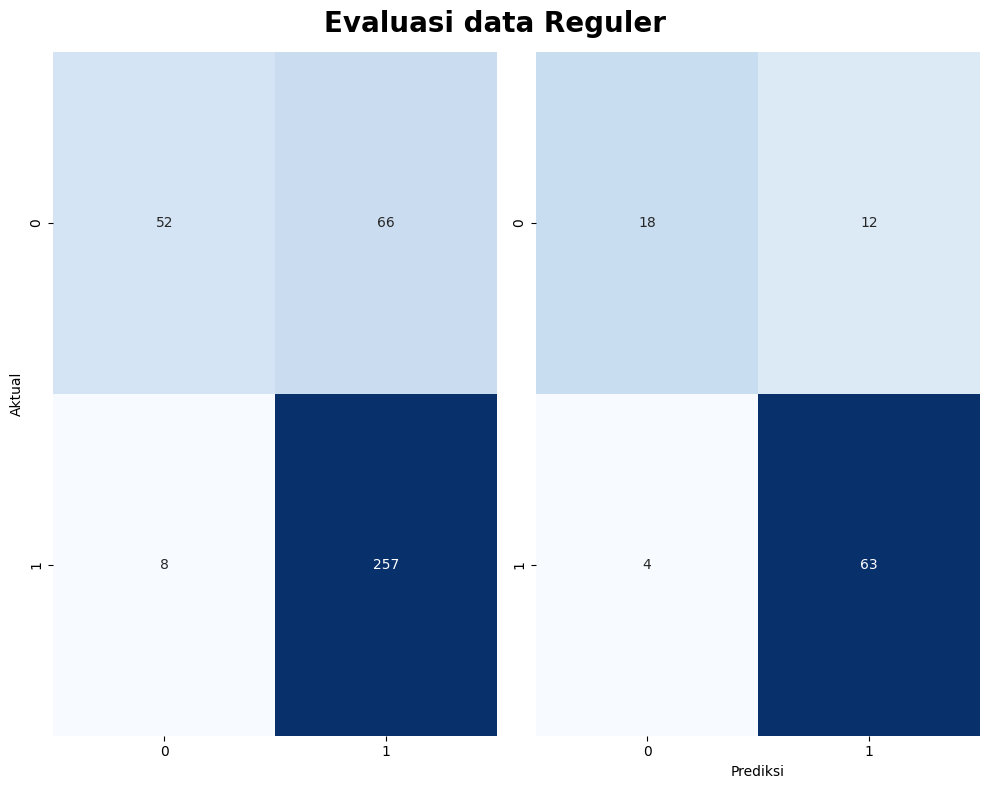

In [350]:
confusion_matrix(y_train, y_pred_train, y_test, y_pred_test, title='Reguler')

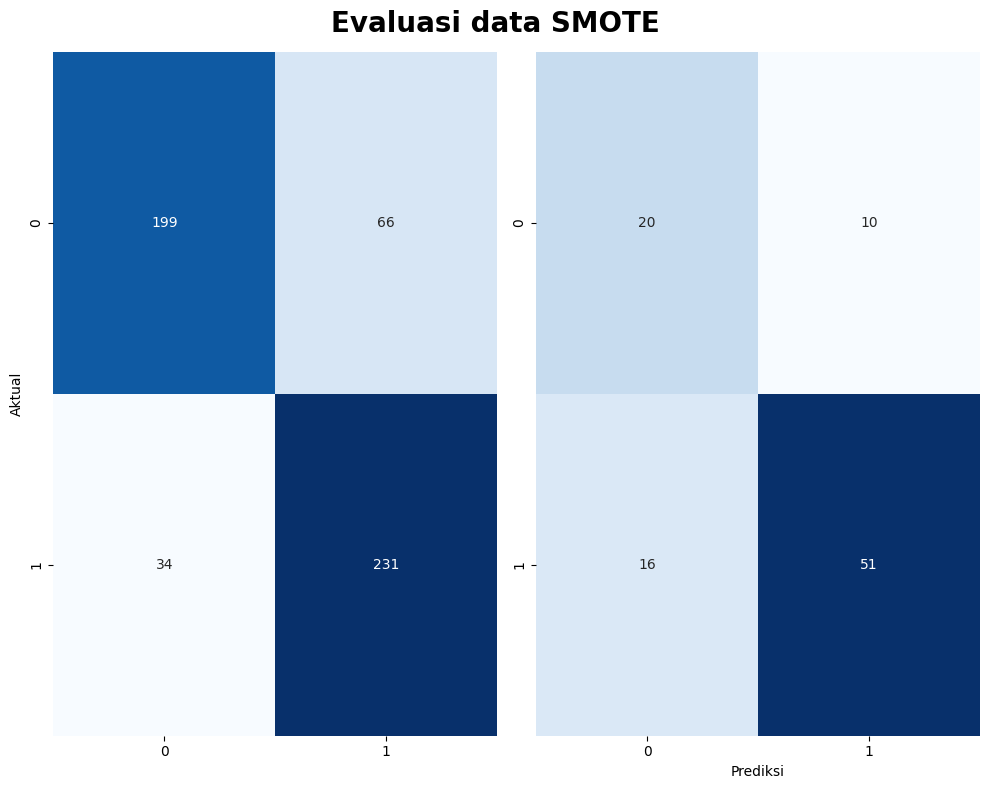

In [351]:
confusion_matrix(y_train_smote, y_pred_train_smote, y_test, y_pred_test_smote, title='SMOTE')

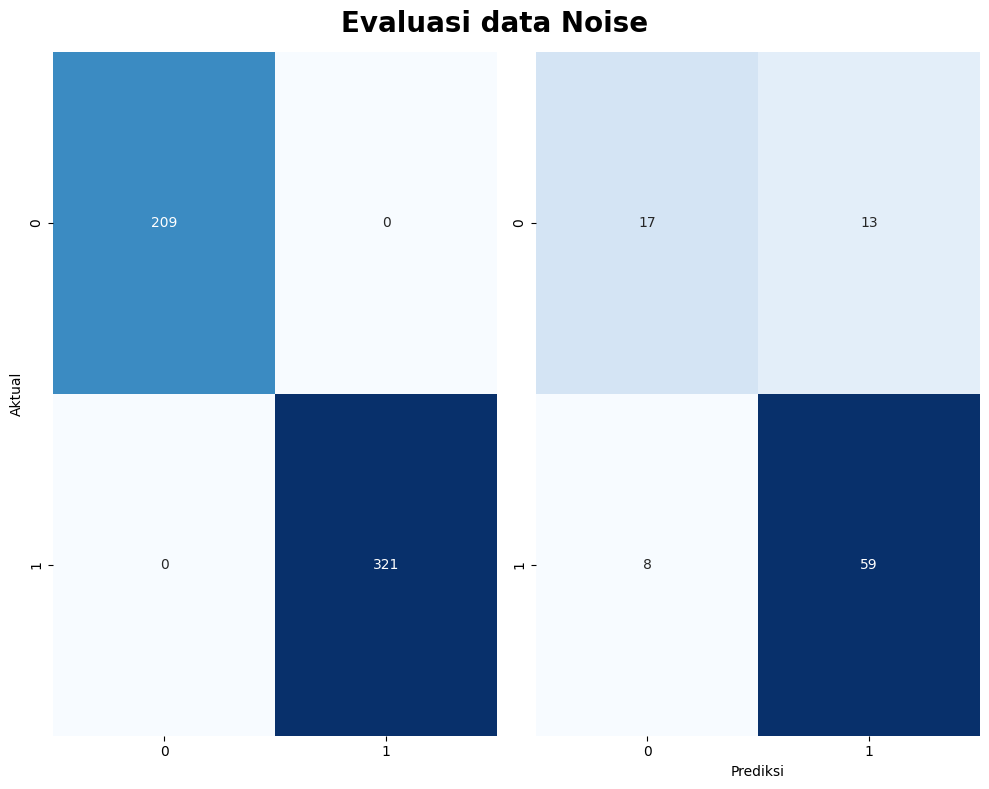

In [352]:
confusion_matrix(y_pred_train_noise, y_pred_train_noise, y_test, y_pred_test_noise, title='Noise')

## **GUI**

In [353]:
feature = X.columns
n_feature = len(feature)

def submit():
    try:
        input_data = []
        for entry in entries:
            value = float(entry.get())
            input_data.append(value)

        input_df = pd.DataFrame([input_data], columns=feature)
        input_scaled = (input_df - X_before.mean()) / X_before.std()
        prediction = model_noise.predict(input_scaled.values)
        messagebox.showinfo('Hasil Prediksi', f'Tipe Pinjaman: {prediction}')
    except ValueError:
        messagebox.showerror('Input Error', 'Masukan Value Yang Benar')
        
root = tk.Tk()
root.configure(bg='#9ECFD4')
root.title('Prediksi Status Pinjaman')
entries = []

title_label = tk.Label(root, text='Prediksi Status Pinjaman', font=('Arial', 26, 'bold'), bg='#9ECFD4')
title_label.grid(row=0, column=0, columnspan=2, padx=25, pady=10)
for i, col in enumerate(feature):
    label = tk.Label(root, text=f'{col}:', bg='#9ECFD4')
    label.grid(row=i+1, column=0, padx=20, pady=5, sticky='w')

    entry = tk.Entry(bg='#7db0b5')
    entry.grid(row=i+1, column=1, padx=20, pady=5)
    entries.append(entry)

submit_btn = tk.Button(root, text='Prediksi', command=submit, bg='#B8DB80')
submit_btn.grid(row=n_feature+1, column=0, columnspan=2, pady=20, ipady=5)

root.mainloop()

In [354]:
a = pd.read_csv('loan-test.csv')
a.head(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [355]:
loan.sample(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
99,79,0,0,1,0,0,1759,3541.0,131.0,360.0,1.0,2,1
505,394,0,0,2,0,0,3510,4416.0,243.0,360.0,1.0,0,1
388,300,0,0,1,0,0,2333,2417.0,136.0,360.0,1.0,1,1
251,196,1,1,2,0,0,3427,0.0,138.0,360.0,1.0,1,0
400,310,0,0,2,1,0,2889,0.0,45.0,180.0,0.0,1,0


In [ ]:
loan_before = pd.read_csv('loan-train.csv')
loan_before.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
